# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('Y_train_balanced.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('Y_test.csv')

In [5]:
print('tamanho', X_train.shape)
print('tamanho', y_train.shape)
print(y_train.value_counts())

tamanho (183, 10)
tamanho (183, 1)
credit_score
High            61
Average         61
Low             61
Name: count, dtype: int64


In [6]:
print('tamanho', X_test.shape)
print('tamanho', y_test.shape)
print(y_test.value_counts())

tamanho (29, 10)
tamanho (29, 1)
credit_score
High            22
Average          4
Low              3
Name: count, dtype: int64


In [7]:
print(X_train.columns)
print(X_test.columns)

Index(['age', 'income', 'number_of_children', 'gender_Male',
       'marital_status_Single', 'education_Bachelor's Degree',
       'education_Doctorate', 'education_High School Diploma',
       'education_Master's Degree', 'home_ownership_Rented'],
      dtype='str')
Index(['age', 'income', 'number_of_children', 'gender_Male',
       'marital_status_Single', 'education_Bachelor's Degree',
       'education_Doctorate', 'education_High School Diploma',
       'education_Master's Degree', 'home_ownership_Rented'],
      dtype='str')


In [8]:
print(y_train.columns)
print(y_test.columns)

Index(['credit_score'], dtype='str')
Index(['credit_score'], dtype='str')


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [9]:
#criando uma instância,, deu erro na dimensão então tive que corrigir com ravel 
naive_churn = GaussianNB()
naive_churn.fit(X_train, y_train)

C:\Users\Regina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

In [10]:
y_pred_train = naive_churn.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train, average='macro')
print('Acurácia', accuracy)
print('Recall', recall)

Acurácia 0.994535519125683
Recall 0.9945355191256832


In [11]:
conf_matrix = confusion_matrix(y_train, y_pred_train)
print("Y_train:", set(y_train))
print("y_pred_train:", set(y_pred_train))
print("shape:", conf_matrix.shape)

Y_train: {'credit_score'}
y_pred_train: {np.str_('Low'), np.str_('Average'), np.str_('High')}
shape: (3, 3)


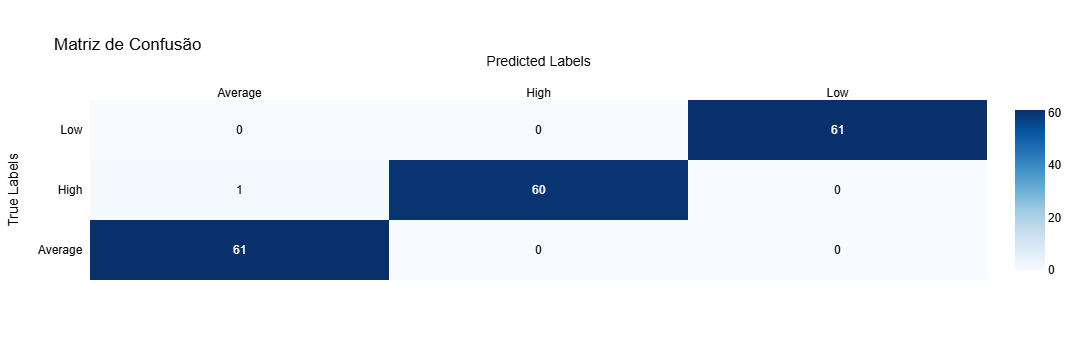

In [12]:
class_names = ['Average', 'High', 'Low']
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted Labels',
    yaxis_title='True Labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)
fig.show()

Uma acurácia de 0.99 mostra que o modelo o modelo está fazendo previsões coretas em 99% das tentativas dos exemplos no cnjunto de dados, ou seja em relação ao total de previsões feitas. A acurácia faz as previsões para os dados de treino para ver se o modelo não está super ajustado aos dados de teste. O recall também é uma métrica de avaliação e e indica a proproção de verdadeiros positivos em relação ao total de positivos reais no conjunto de dados. <br>
 <br>
 A matriz de confusão expandida pode ser interpretada a partir da separação das linhas e coluna onde em sua interseção como na correlação a diagonal vai representar os acertos para cada uma das classes. As linhas abrigam os valores reais já as colunas os valores previstos. Nesse caso, o modelo acertou todos os registros da classe low e average, já na classe high errou apenas uma suposição.
  <br>
 <br>
Uma acurácia e recall tão elevados chamaram a minha atenção, pensei que poderia ser algum problema no balanceamento da base treino, um balanceamento incorreto dos dados de teste ou overfitting. Após investigação esse valor tão alto pode ser um reflexo dos poucos registros, das variáveis possuírem boa separação entre as classes, além do próprio fato do o modelo está sendo testado nos próprios dados que ele já viu durante o treinamento. Todos esses fatores normalmente vão gerar métricas artificialmente altas. A pequena diferença entre treino e teste também sugere a ausência de overfitting significativo.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [14]:
y_pred_test = naive_churn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test, average='macro')
print('Acurácia', accuracy)
print('Recall', recall)
conf_matrix = confusion_matrix(y_test, y_pred_test)
conf_matrix


Acurácia 0.9655172413793104
Recall 0.9848484848484849


array([[ 4,  0,  0],
       [ 1, 21,  0],
       [ 0,  0,  3]])

In [15]:
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Y_test:", set(y_test))
print("y_pred_test:", set(y_pred_test))
print("shape:", conf_matrix.shape)


Y_test: {'credit_score'}
y_pred_test: {np.str_('Low'), np.str_('Average'), np.str_('High')}
shape: (3, 3)


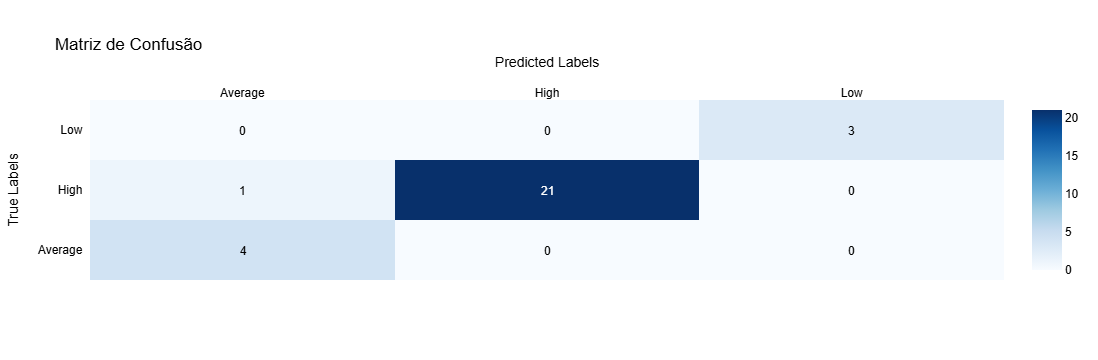

In [16]:
class_names = ['Average', 'High', 'Low']
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted Labels',
    yaxis_title='True Labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)
fig.show()

Assim como na base de treino o modelo teve um excelente resultado, apresentando acurácia de 0.96 e recall de 0.98 que podem ser entendidos como 96% de acertos do total de tentativas e o recall indica que o modelo cnseguiu classificar corretamente quase todos os exemplos de cada classe. Já a matriz de confusão mostra que o modelo classificou corretamente todos os da classe low e average e dessa vez errou uma classificação na classe high.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.

O objetivo do projeto foi aplicar o algoritmo Gaussian Naive Bayes a uma base de crédito já trabalhada anteriormente, com a finalidade de prever corretamente as classes de crédito por meio da identificação de padrões nos dados. Foi desenvolvido um modelo capaz de classificar o credit score dos clientes em diferentes categorias, como “High”, “Average” e “Low”. Em seguida, foram utilizadas métricas como acurácia, recall e matriz de confusão para avaliar o desempenho do algoritmo e também nossa compreensão sobre o funcionamento desse tipo de ferramenta e as métricas que podem ser usadas para avaliar o desempenho do modelo.

Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!